In [6]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached keras-2.11.0-py2.py3-none-any.whl (1.7 MB)
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikeras 0.13.0 requires keras>=3.2.0, but you have keras 2.11.0 which is incompatible.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=42)

df = pd.DataFrame(X, columns=[f"Feature_{i+1}" for i in range(X.shape[1])])
df['Target'] = y
df.head()


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,-0.439643,0.542547,-0.822420,0.401366,-0.854840,0
1,2.822231,-2.480859,-1.147691,-2.101131,3.040278,1
2,1.618386,-1.369478,-2.084113,-1.179659,1.613602,1
3,1.659048,-0.615202,1.112688,-0.835098,-0.272205,1
4,1.849824,-1.679456,-0.926698,-1.402509,2.123129,1


In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_sklearn = pca.fit_transform(X)

print("Principal components (sklearn):")
print(pca.components_)


Principal components (sklearn):
[[ 0.66558964 -0.45567933 -0.01074741 -0.4341306   0.40095124]
 [-0.51502168 -0.11892024  0.00505902  0.11220619  0.84142428]]


In [3]:
import numpy as np

X_centered = X - np.mean(X, axis=0)

U, S, Vt = np.linalg.svd(X_centered)

principal_components = Vt[:2]
print("Principal components (manual):")
print(principal_components)


Principal components (manual):
[[ 0.66558964 -0.45567933 -0.01074741 -0.4341306   0.40095124]
 [-0.51502168 -0.11892024  0.00505902  0.11220619  0.84142428]]


In [4]:

pca = PCA(0.95)
X_pca_95 = pca.fit_transform(X)

print(f"Number of components that explain 95% variance: {X_pca_95.shape[1]}")


Number of components that explain 95% variance: 3


In [30]:
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.56350594 0.27669897 0.15979509]


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential()
model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


2025-02-01 17:26:12.413738: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025-02-01 17:26:24.871123: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/20
25/25 [==============================] - 3s 40ms/step - loss: 0.7123 - accuracy: 0.4625 - val_loss: 0.6441 - val_accuracy: 0.7350
Epoch 2/20
25/25 [==============================] - 0s 7ms/step - loss: 0.5771 - accuracy: 0.8475 - val_loss: 0.5238 - val_accuracy: 0.8300
Epoch 3/20
25/25 [==============================] - 0s 12ms/step - loss: 0.4799 - accuracy: 0.8587 - val_loss: 0.4319 - val_accuracy: 0.8400
Epoch 4/20
25/25 [==============================] - 0s 9ms/step - loss: 0.4116 - accuracy: 0.8550 - val_loss: 0.3707 - val_accuracy: 0.8500
Epoch 5/20
25/25 [==============================] - 0s 9ms/step - loss: 0.3719 - accuracy: 0.8575 - val_loss: 0.3350 - val_accuracy: 0.8500
Epoch 6/20
25/25 [==============================] - 0s 10ms/step - loss: 0.3524 - accuracy: 0.8575 - val_loss: 0.3146 - val_accuracy: 0.8550
Epoch 7/20
25/25 [==============================] - 0s 8ms/step - loss: 0.3427 - accuracy: 0.8550 - val_loss: 0.3042 - val_accuracy: 0.8600
Epoch 8/20
25/25 

In [6]:
X_train_pca, X_test_pca = train_test_split(X_pca_sklearn, test_size=0.2, random_state=42)

model_pca = Sequential()
model_pca.add(Dense(32, input_dim=X_train_pca.shape[1], activation='relu'))
model_pca.add(Dense(16, activation='relu'))
model_pca.add(Dense(1, activation='sigmoid'))

model_pca.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model_pca.fit(X_train_pca, y_train, epochs=20, batch_size=32, validation_data=(X_test_pca, y_test))


Epoch 1/20
25/25 [==============================] - 2s 36ms/step - loss: 0.6219 - accuracy: 0.6888 - val_loss: 0.5494 - val_accuracy: 0.8500
Epoch 2/20
25/25 [==============================] - 0s 7ms/step - loss: 0.5321 - accuracy: 0.8500 - val_loss: 0.4855 - val_accuracy: 0.8600
Epoch 3/20
25/25 [==============================] - 0s 8ms/step - loss: 0.4829 - accuracy: 0.8537 - val_loss: 0.4393 - val_accuracy: 0.8600
Epoch 4/20
25/25 [==============================] - 0s 6ms/step - loss: 0.4455 - accuracy: 0.8562 - val_loss: 0.4027 - val_accuracy: 0.8600
Epoch 5/20
25/25 [==============================] - 0s 20ms/step - loss: 0.4160 - accuracy: 0.8537 - val_loss: 0.3730 - val_accuracy: 0.8750
Epoch 6/20
25/25 [==============================] - 0s 8ms/step - loss: 0.3898 - accuracy: 0.8500 - val_loss: 0.3498 - val_accuracy: 0.8750
Epoch 7/20
25/25 [==============================] - 0s 6ms/step - loss: 0.3709 - accuracy: 0.8512 - val_loss: 0.3306 - val_accuracy: 0.8800
Epoch 8/20
25/25 [

In [7]:
from sklearn.decomposition import KernelPCA

kernel_pca_linear = KernelPCA(kernel='linear', n_components=2)
kernel_pca_rbf = KernelPCA(kernel='rbf', gamma=15, n_components=2)
kernel_pca_sigmoid = KernelPCA(kernel='sigmoid', gamma=15, coef0=1, n_components=2)

X_pca_linear = kernel_pca_linear.fit_transform(X)
X_pca_rbf = kernel_pca_rbf.fit_transform(X)
X_pca_sigmoid = kernel_pca_sigmoid.fit_transform(X)

def train_model(X_train, y_train, X_test, y_test):
    model = Sequential()
    model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


X_train_kp, X_test_kp, y_train, y_test = train_test_split(X_pca_linear, y, test_size=0.2, random_state=42)
train_model(X_train_kp, y_train, X_test_kp, y_test)

X_train_kp, X_test_kp = train_test_split(X_pca_rbf, test_size=0.2, random_state=42)
train_model(X_train_kp, y_train, X_test_kp, y_test)

X_train_kp, X_test_kp = train_test_split(X_pca_sigmoid, test_size=0.2, random_state=42)
train_model(X_train_kp, y_train, X_test_kp, y_test)


Epoch 1/20
25/25 [==============================] - 3s 26ms/step - loss: 0.6681 - accuracy: 0.6575 - val_loss: 0.6059 - val_accuracy: 0.7200
Epoch 2/20
25/25 [==============================] - 0s 15ms/step - loss: 0.5482 - accuracy: 0.7962 - val_loss: 0.5002 - val_accuracy: 0.8700
Epoch 3/20
25/25 [==============================] - 0s 9ms/step - loss: 0.4671 - accuracy: 0.8500 - val_loss: 0.4171 - val_accuracy: 0.8700
Epoch 4/20
25/25 [==============================] - 0s 9ms/step - loss: 0.4063 - accuracy: 0.8612 - val_loss: 0.3578 - val_accuracy: 0.8650
Epoch 5/20
25/25 [==============================] - 0s 7ms/step - loss: 0.3648 - accuracy: 0.8625 - val_loss: 0.3234 - val_accuracy: 0.8650
Epoch 6/20
25/25 [==============================] - 0s 6ms/step - loss: 0.3442 - accuracy: 0.8637 - val_loss: 0.3005 - val_accuracy: 0.8650
Epoch 7/20
25/25 [==============================] - 0s 6ms/step - loss: 0.3338 - accuracy: 0.8587 - val_loss: 0.2924 - val_accuracy: 0.8750
Epoch 8/20
25/25 [

In [13]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import KernelPCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.preprocessing import StandardScaler

def create_nn_model(input_dim=2):  
    model = Sequential()
    model.add(Dense(32, input_dim=input_dim, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model


model = KerasClassifier(build_fn=create_nn_model, epochs=20, batch_size=32, verbose=0)


kpca = KernelPCA(n_components=2, eigen_solver="auto", remove_zero_eig=True)


pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('kpca', kpca),
    ('nn', model)
])

param_grid = {
    'kpca__kernel': ['linear', 'rbf'],  
    'kpca__gamma': [0.01, 0.1, 0.5],  
    'nn__batch_size': [16, 32],
    'nn__epochs': [10, 20],
    'nn__input_dim': [2]  
}


X = np.random.rand(100, 3)  
y = np.random.randint(0, 2, 100)  

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=2)  # Added scoring and verbose
grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)



/var/folders/xd/pp6r85cs5fbdyytc3tf2x8ww0000gn/T/ipykernel_37101/2840255930.py:21: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_nn_model, epochs=20, batch_size=32, verbose=0)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
2/2 [==============================] - 1s 16ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=linear, nn__batch_size=16, nn__epochs=10, nn__input_dim=2; total time=   7.0s
2/2 [==============================] - 0s 4ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=linear, nn__batch_size=16, nn__epochs=10, nn__input_dim=2; total time=   2.0s
2/2 [==============================] - 0s 4ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=linear, nn__batch_size=16, nn__epochs=10, nn__input_dim=2; total time=   3.8s
2/2 [==============================] - 0s 4ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=linear, nn__batch_size=16, nn__epochs=20, nn__input_dim=2; total time=   1.8s
2/2 [==============================] - 0s 3ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=linear, nn__batch_size=16, nn__epochs=20, nn__input_dim=2; total time=   1.9s
2/2 [==============================] - 0s 6ms/step
[CV] END kpca__gamma=0.01, kpca__kernel=li

/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best parameters: {'kpca__gamma': 0.5, 'kpca__kernel': 'linear', 'nn__batch_size': 32, 'nn__epochs': 10, 'nn__input_dim': 2}


Classification

In [14]:
import tensorflow as tf
from tensorflow import keras
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

fashion_mnist = keras.datasets.fashion_mnist
(X_train_fmnist, y_train_fmnist), (X_test_fmnist, y_test_fmnist) = fashion_mnist.load_data()

iris = datasets.load_iris()
X_iris, y_iris = iris.data, iris.target

encoder = OneHotEncoder(sparse_output=False)
y_iris = encoder.fit_transform(y_iris.reshape(-1, 1))

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)


In [15]:

X_train_fmnist = X_train_fmnist / 255.0
X_test_fmnist = X_test_fmnist / 255.0


model_fmnist = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  
])

model_fmnist.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

history_fmnist = model_fmnist.fit(X_train_fmnist, y_train_fmnist, 
                                  epochs=20, batch_size=32, 
                                  validation_data=(X_test_fmnist, y_test_fmnist))


Epoch 1/20
1875/1875 [==============================] - 14s 6ms/step - loss: 0.4948 - accuracy: 0.8225 - val_loss: 0.4369 - val_accuracy: 0.8367
Epoch 2/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3672 - accuracy: 0.8653 - val_loss: 0.4030 - val_accuracy: 0.8533
Epoch 3/20
1875/1875 [==============================] - 8s 5ms/step - loss: 0.3322 - accuracy: 0.8787 - val_loss: 0.3669 - val_accuracy: 0.8668
Epoch 4/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3096 - accuracy: 0.8859 - val_loss: 0.3463 - val_accuracy: 0.8749
Epoch 5/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2886 - accuracy: 0.8924 - val_loss: 0.3574 - val_accuracy: 0.8743
Epoch 6/20
1875/1875 [==============================] - 13s 7ms/step - loss: 0.2767 - accuracy: 0.8971 - val_loss: 0.3459 - val_accuracy: 0.8797
Epoch 7/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.2658 - accuracy: 0.9003 - val_loss: 0.3412 - val_accurac

In [16]:

scaler = StandardScaler()
X_train_iris = scaler.fit_transform(X_train_iris)
X_test_iris = scaler.transform(X_test_iris)

model_iris = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax')  


model_iris.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

history_iris = model_iris.fit(X_train_iris, y_train_iris, 
                              epochs=50, batch_size=16, 
                              validation_data=(X_test_iris, y_test_iris))


Epoch 1/50
8/8 [==============================] - 2s 49ms/step - loss: 1.1258 - accuracy: 0.3167 - val_loss: 1.0717 - val_accuracy: 0.4667
Epoch 2/50
8/8 [==============================] - 0s 16ms/step - loss: 1.0538 - accuracy: 0.6167 - val_loss: 1.0068 - val_accuracy: 0.7000
Epoch 3/50
8/8 [==============================] - 0s 13ms/step - loss: 0.9918 - accuracy: 0.7000 - val_loss: 0.9428 - val_accuracy: 0.7333
Epoch 4/50
8/8 [==============================] - 0s 11ms/step - loss: 0.9323 - accuracy: 0.7417 - val_loss: 0.8819 - val_accuracy: 0.7667
Epoch 5/50
8/8 [==============================] - 0s 12ms/step - loss: 0.8771 - accuracy: 0.7833 - val_loss: 0.8209 - val_accuracy: 0.8667
Epoch 6/50
8/8 [==============================] - 0s 11ms/step - loss: 0.8218 - accuracy: 0.8333 - val_loss: 0.7621 - val_accuracy: 0.8667
Epoch 7/50
8/8 [==============================] - 0s 11ms/step - loss: 0.7690 - accuracy: 0.8417 - val_loss: 0.7055 - val_accuracy: 0.9000
Epoch 8/50
8/8 [===========

In [17]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV


def create_model(activation='relu', optimizer='adam'):
    model = keras.Sequential([
        keras.layers.Dense(64, activation=activation, input_shape=(4,)),
        keras.layers.Dense(32, activation=activation),
        keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model = KerasClassifier(build_fn=create_model, epochs=30, batch_size=16, verbose=0)


param_grid = {
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'sgd'],
    'batch_size': [16, 32]
}


grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
grid.fit(X_train_iris, y_train_iris)


print("Best Hyperparameters:", grid.best_params_)


/var/folders/xd/pp6r85cs5fbdyytc3tf2x8ww0000gn/T/ipykernel_37101/2159438544.py:15: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasClassifier(build_fn=create_model, epochs=30, batch_size=16, verbose=0)


/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters: {'activation': 'tanh', 'batch_size': 16, 'optimizer': 'adam'}


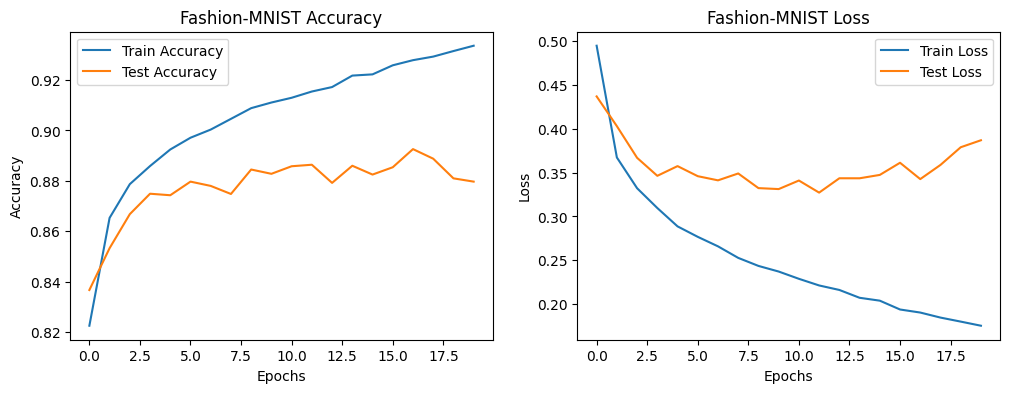

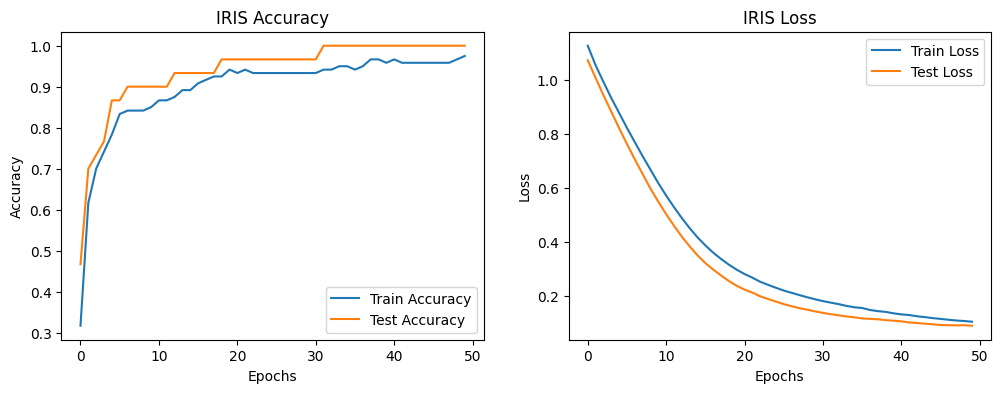

In [18]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"{title} Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"{title} Loss")

    plt.show()

plot_history(history_fmnist, "Fashion-MNIST")

plot_history(history_iris, "IRIS")


In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

model_fmnist.fit(X_train_fmnist, y_train_fmnist, 
                 epochs=20, batch_size=32, 
                 validation_data=(X_test_fmnist, y_test_fmnist), 
                 callbacks=callbacks)


Epoch 1/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1614 - accuracy: 0.9388 - val_loss: 0.3766 - val_accuracy: 0.8897
Epoch 2/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1541 - accuracy: 0.9418 - val_loss: 0.4243 - val_accuracy: 0.8883
Epoch 3/20
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1536 - accuracy: 0.9413 - val_loss: 0.4037 - val_accuracy: 0.8852
Epoch 4/20
1875/1875 [==============================] - 11s 6ms/step - loss: 0.1490 - accuracy: 0.9437 - val_loss: 0.4253 - val_accuracy: 0.8796
Epoch 5/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1462 - accuracy: 0.9441 - val_loss: 0.4092 - val_accuracy: 0.8833
Epoch 6/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.1423 - accuracy: 0.9455 - val_loss: 0.4539 - val_accuracy: 0.8810


In [21]:

model_fmnist.save_weights("fashion_mnist_weights.h5")

model_fmnist.load_weights("fashion_mnist_weights.h5")


In [22]:

model_fmnist.save("fashion_mnist_model.h5")

loaded_model = keras.models.load_model("fashion_mnist_model.h5")

loss, acc = loaded_model.evaluate(X_test_fmnist, y_test_fmnist)
print(f"Loaded Model Accuracy: {acc:.4f}")


313/313 [==============================] - 2s 6ms/step - loss: 0.3766 - accuracy: 0.8897
Loaded Model Accuracy: 0.8897


Regression


In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

housing = fetch_california_housing()

X, y = housing.data, housing.target 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),
              loss='mse',  
              metrics=['mae']) 

history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)


Epoch 1/50
516/516 [==============================] - 4s 4ms/step - loss: 0.5673 - mae: 0.5090 - val_loss: 0.4324 - val_mae: 0.4927
Epoch 2/50
516/516 [==============================] - 2s 4ms/step - loss: 0.4308 - mae: 0.4365 - val_loss: 0.3842 - val_mae: 0.4393
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3448 - mae: 0.4100 - val_loss: 0.3455 - val_mae: 0.4109
Epoch 4/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3358 - mae: 0.4024 - val_loss: 0.3536 - val_mae: 0.4011
Epoch 5/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3289 - mae: 0.3972 - val_loss: 0.3507 - val_mae: 0.3951
Epoch 6/50
516/516 [==============================] - 7s 13ms/step - loss: 0.3193 - mae: 0.3922 - val_loss: 0.4000 - val_mae: 0.3958
Epoch 7/50
516/516 [==============================] - 3s 6ms/step - loss: 0.3201 - mae: 0.3898 - val_loss: 0.3280 - val_mae: 0.3941
Epoch 8/50
516/516 [==============================] - 3s 6ms/step - loss: 0

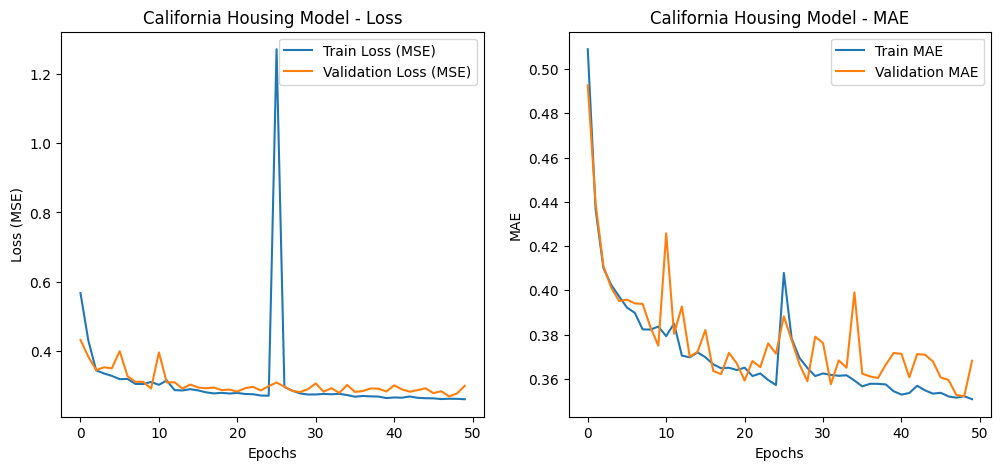

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.title(f'{title} - Loss')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.title(f'{title} - MAE')

    plt.show()


plot_history(history, "California Housing Model")


Epoch 1/50
516/516 [==============================] - 4s 4ms/step - loss: 1.0483 - mae: 0.6922 - val_loss: 0.4591 - val_mae: 0.4749
Epoch 2/50
516/516 [==============================] - 2s 3ms/step - loss: 0.4128 - mae: 0.4575 - val_loss: 0.3909 - val_mae: 0.4530
Epoch 3/50
516/516 [==============================] - 2s 3ms/step - loss: 0.3777 - mae: 0.4359 - val_loss: 0.3803 - val_mae: 0.4441
Epoch 4/50
516/516 [==============================] - 3s 6ms/step - loss: 0.3575 - mae: 0.4224 - val_loss: 0.3561 - val_mae: 0.4159
Epoch 5/50
516/516 [==============================] - 3s 5ms/step - loss: 0.3451 - mae: 0.4129 - val_loss: 0.3498 - val_mae: 0.4321
Epoch 6/50
516/516 [==============================] - 2s 4ms/step - loss: 0.3277 - mae: 0.4009 - val_loss: 0.3468 - val_mae: 0.4067
Epoch 7/50
516/516 [==============================] - 2s 4ms/step - loss: 0.3190 - mae: 0.3931 - val_loss: 0.3201 - val_mae: 0.4028
Epoch 8/50
516/516 [==============================] - 2s 4ms/step - loss: 0.

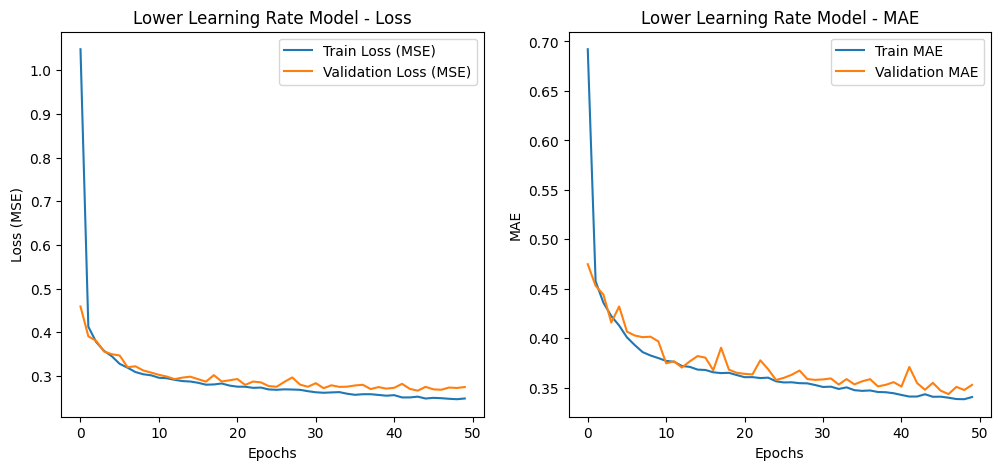

In [26]:

model_lr = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_lr.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='mse',
                 metrics=['mae'])

history_lr = model_lr.fit(X_train, y_train, epochs=50, batch_size=32,
                          validation_data=(X_test, y_test), verbose=1)

plot_history(history_lr, "Lower Learning Rate Model")


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_california_model.h5', save_best_only=True)
]

model.fit(X_train, y_train, epochs=50, batch_size=32,
          validation_data=(X_test, y_test),
          callbacks=callbacks)


Epoch 1/50
516/516 [==============================] - 3s 6ms/step - loss: 0.2653 - mae: 0.3524 - val_loss: 0.3226 - val_mae: 0.4111
Epoch 2/50
516/516 [==============================] - 2s 4ms/step - loss: 0.2652 - mae: 0.3545 - val_loss: 0.3077 - val_mae: 0.3652
Epoch 3/50
516/516 [==============================] - 2s 5ms/step - loss: 0.2610 - mae: 0.3524 - val_loss: 0.2834 - val_mae: 0.3642
Epoch 4/50
516/516 [==============================] - 2s 4ms/step - loss: 0.2591 - mae: 0.3486 - val_loss: 0.2832 - val_mae: 0.3683
Epoch 5/50
516/516 [==============================] - 2s 4ms/step - loss: 0.2622 - mae: 0.3513 - val_loss: 0.2833 - val_mae: 0.3584
Epoch 6/50
516/516 [==============================] - 2s 4ms/step - loss: 0.2604 - mae: 0.3513 - val_loss: 0.2847 - val_mae: 0.3577
Epoch 7/50
516/516 [==============================] - 2s 4ms/step - loss: 0.2655 - mae: 0.3545 - val_loss: 0.2730 - val_mae: 0.3493
Epoch 8/50
516/516 [==============================] - 2s 4ms/step - loss: 0.

In [28]:

model.save("california_housing_model.h5")


In [29]:

loaded_model = keras.models.load_model("california_housing_model.h5")


loss, mae = loaded_model.evaluate(X_test, y_test)
print(f"Loaded Model - Test MAE: {mae:.4f}")


129/129 [==============================] - 1s 4ms/step - loss: 0.2730 - mae: 0.3493
Loaded Model - Test MAE: 0.3493
